<a href="https://colab.research.google.com/github/aronnaiqbal/220153_DT/blob/main/220153_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

In [62]:
url = "https://raw.githubusercontent.com/aronnaiqbal/220153_DT/refs/heads/main/Dataset/Titanic-Dataset.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
d

In [64]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [65]:
print("Dataset Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset Shape: (891, 12)
Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [67]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [68]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


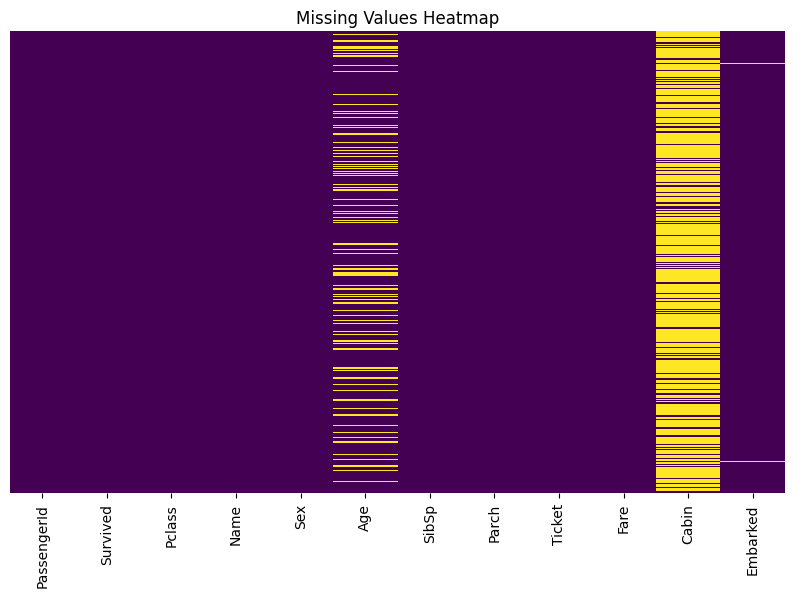

In [69]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title("Missing Values Heatmap")
plt.show()

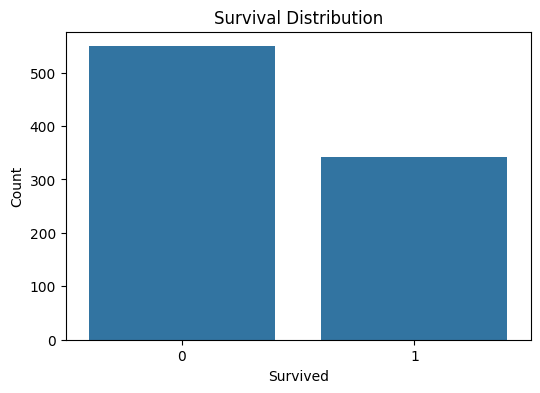

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Survived',
    data=df
)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

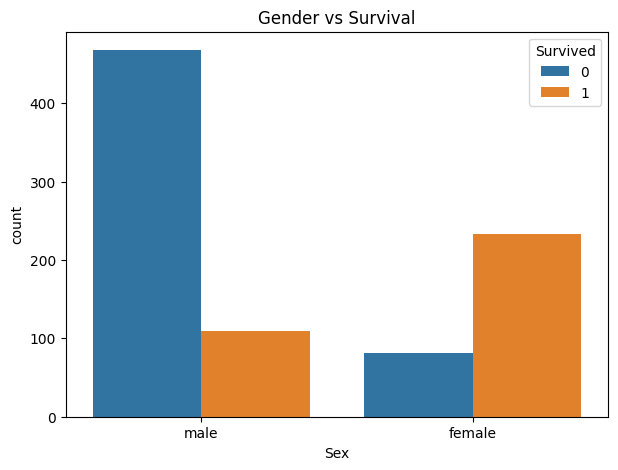

In [71]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Gender vs Survival")

plt.show()

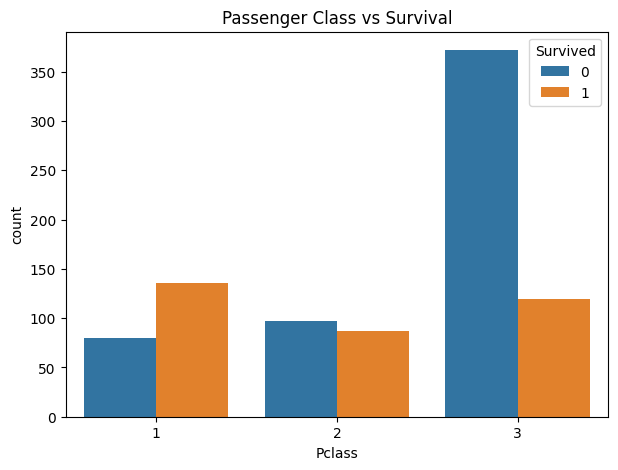

In [72]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

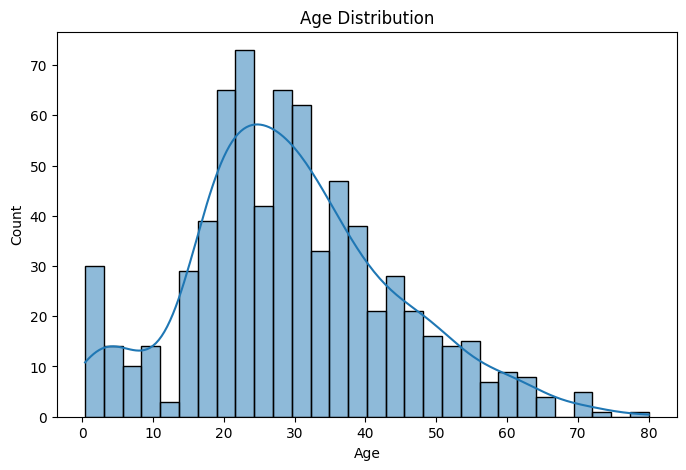

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

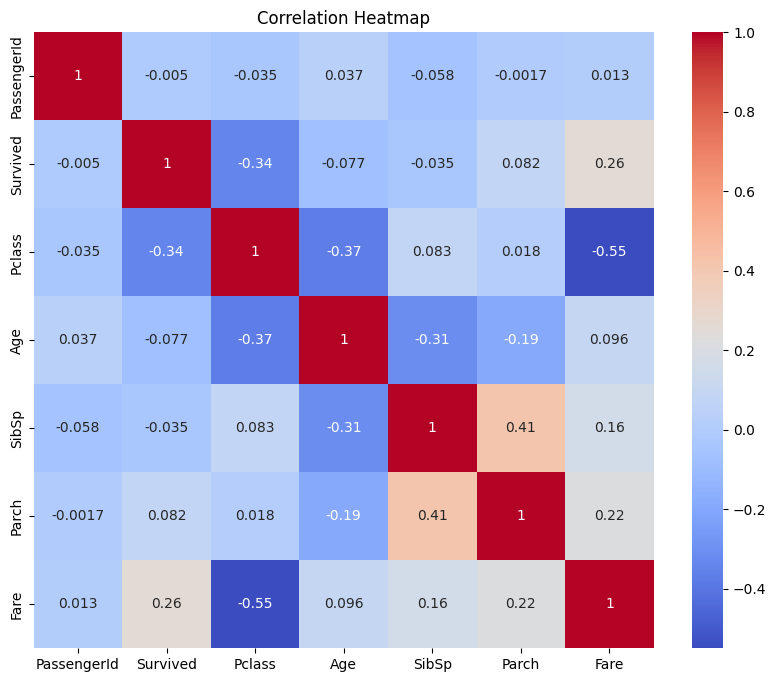

In [74]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [75]:
df.drop(
    columns=['PassengerId','Name','Ticket','Cabin'],
    errors='ignore',
    inplace=True
)

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

if 'Age' in df.columns:
    df[['Age']] = num_imputer.fit_transform(df[['Age']])

if 'Embarked' in df.columns:
    df[['Embarked']] = cat_imputer.fit_transform(df[['Embarked']])

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [76]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [79]:
cart_params = {
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

cart_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion='gini',
        random_state=42
    ),
    cart_params,
    cv=5,
    scoring='accuracy'
)

cart_grid.fit(X_train,y_train)

cart_model = cart_grid.best_estimator_

print(cart_grid.best_params_)

{'max_depth': 5, 'min_samples_split': 10}


In [80]:
id3_params = {
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

id3_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion='entropy',
        random_state=42
    ),
    id3_params,
    cv=5,
    scoring='accuracy'
)

id3_grid.fit(X_train,y_train)

id3_model = id3_grid.best_estimator_

print(id3_grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2}


In [81]:
cart_pred = cart_model.predict(X_test)
cart_prob = cart_model.predict_proba(X_test)[:,1]

id3_pred = id3_model.predict(X_test)
id3_prob = id3_model.predict_proba(X_test)[:,1]

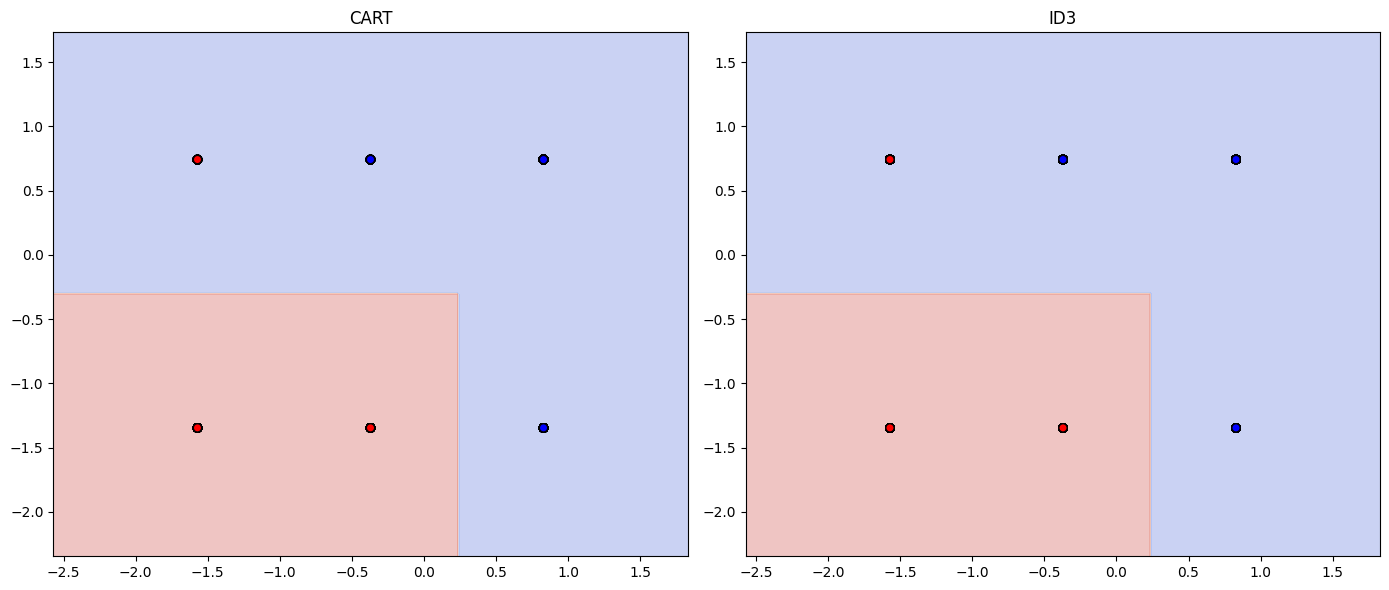

In [82]:
X_vis = X_train[:, :2]

cart_vis = DecisionTreeClassifier(
    criterion='gini',
    max_depth=cart_model.max_depth
)

cart_vis.fit(X_vis,y_train)

id3_vis = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=id3_model.max_depth
)

id3_vis.fit(X_vis,y_train)

x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min,x_max,0.02),
    np.arange(y_min,y_max,0.02)
)

fig, ax = plt.subplots(1,2,figsize=(14,6))

for model,title,axis in [
    (cart_vis,'CART',ax[0]),
    (id3_vis,'ID3',ax[1])
]:

    Z = model.predict(
        np.c_[xx.ravel(), yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    axis.contourf(
        xx,
        yy,
        Z,
        alpha=0.3,
        cmap='coolwarm'
    )

    axis.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=y_train,
        cmap='bwr',
        edgecolor='black'
    )

    axis.set_title(title)

plt.tight_layout()
plt.show()

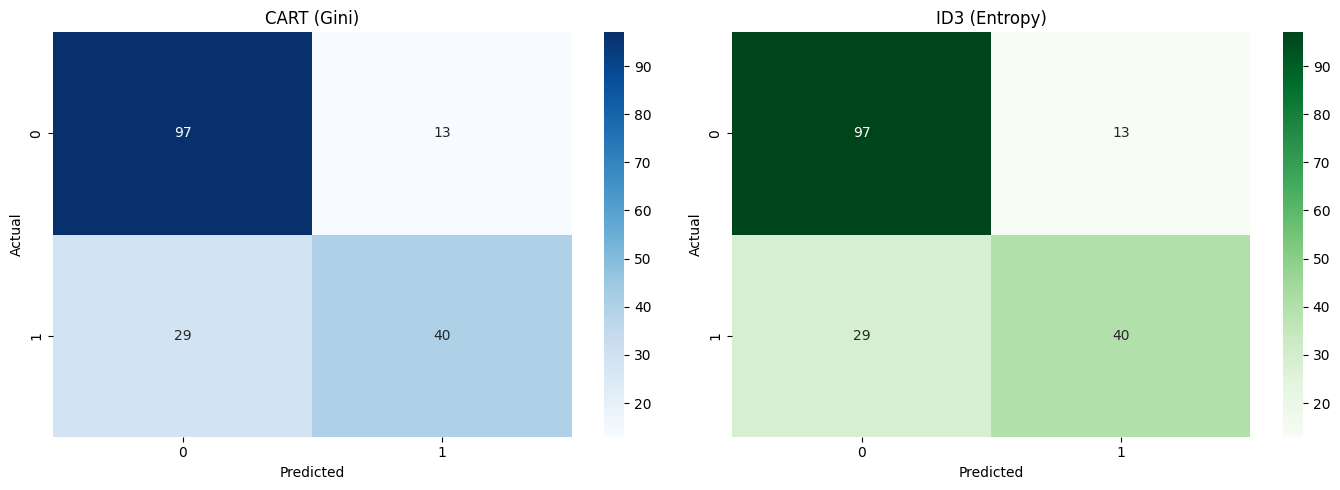

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cart_cm = confusion_matrix(y_test, cart_pred)
id3_cm = confusion_matrix(y_test, id3_pred)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cart_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("CART (Gini)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(
    id3_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("ID3 (Entropy)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

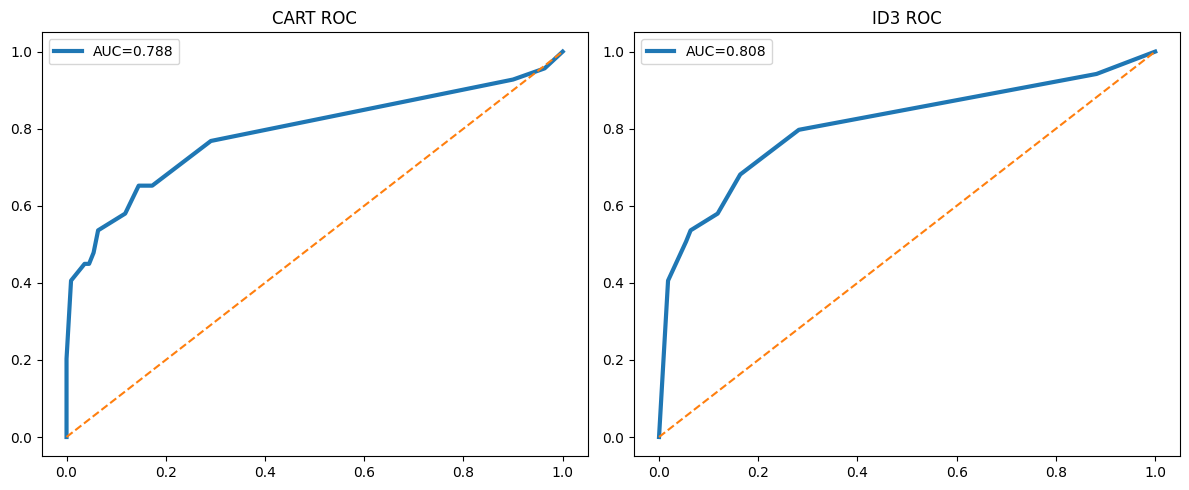

In [84]:
cart_fpr, cart_tpr, _ = roc_curve(y_test,cart_prob)
id3_fpr, id3_tpr, _ = roc_curve(y_test,id3_prob)

fig, ax = plt.subplots(1,2,figsize=(12,5))

cart_auc = roc_auc_score(y_test,cart_prob)
id3_auc = roc_auc_score(y_test,id3_prob)

ax[0].plot(
    cart_fpr,
    cart_tpr,
    linewidth=3,
    label=f'AUC={cart_auc:.3f}'
)

ax[0].plot([0,1],[0,1],'--')
ax[0].legend()
ax[0].set_title("CART ROC")

ax[1].plot(
    id3_fpr,
    id3_tpr,
    linewidth=3,
    label=f'AUC={id3_auc:.3f}'
)

ax[1].plot([0,1],[0,1],'--')
ax[1].legend()
ax[1].set_title("ID3 ROC")

plt.tight_layout()
plt.show()

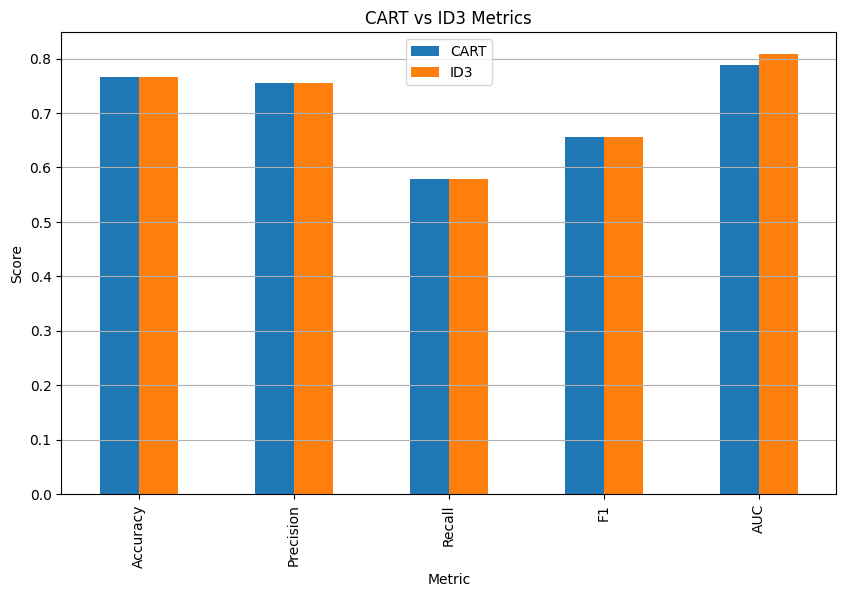

In [85]:
metrics = pd.DataFrame({

    'Metric':['Accuracy','Precision','Recall','F1','AUC'],

    'CART':[

        accuracy_score(y_test,cart_pred),
        precision_score(y_test,cart_pred),
        recall_score(y_test,cart_pred),
        f1_score(y_test,cart_pred),
        roc_auc_score(y_test,cart_prob)
    ],

    'ID3':[

        accuracy_score(y_test,id3_pred),
        precision_score(y_test,id3_pred),
        recall_score(y_test,id3_pred),
        f1_score(y_test,id3_pred),
        roc_auc_score(y_test,id3_prob)
    ]
})

metrics.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("CART vs ID3 Metrics")
plt.ylabel("Score")
plt.grid(axis='y')
plt.show()

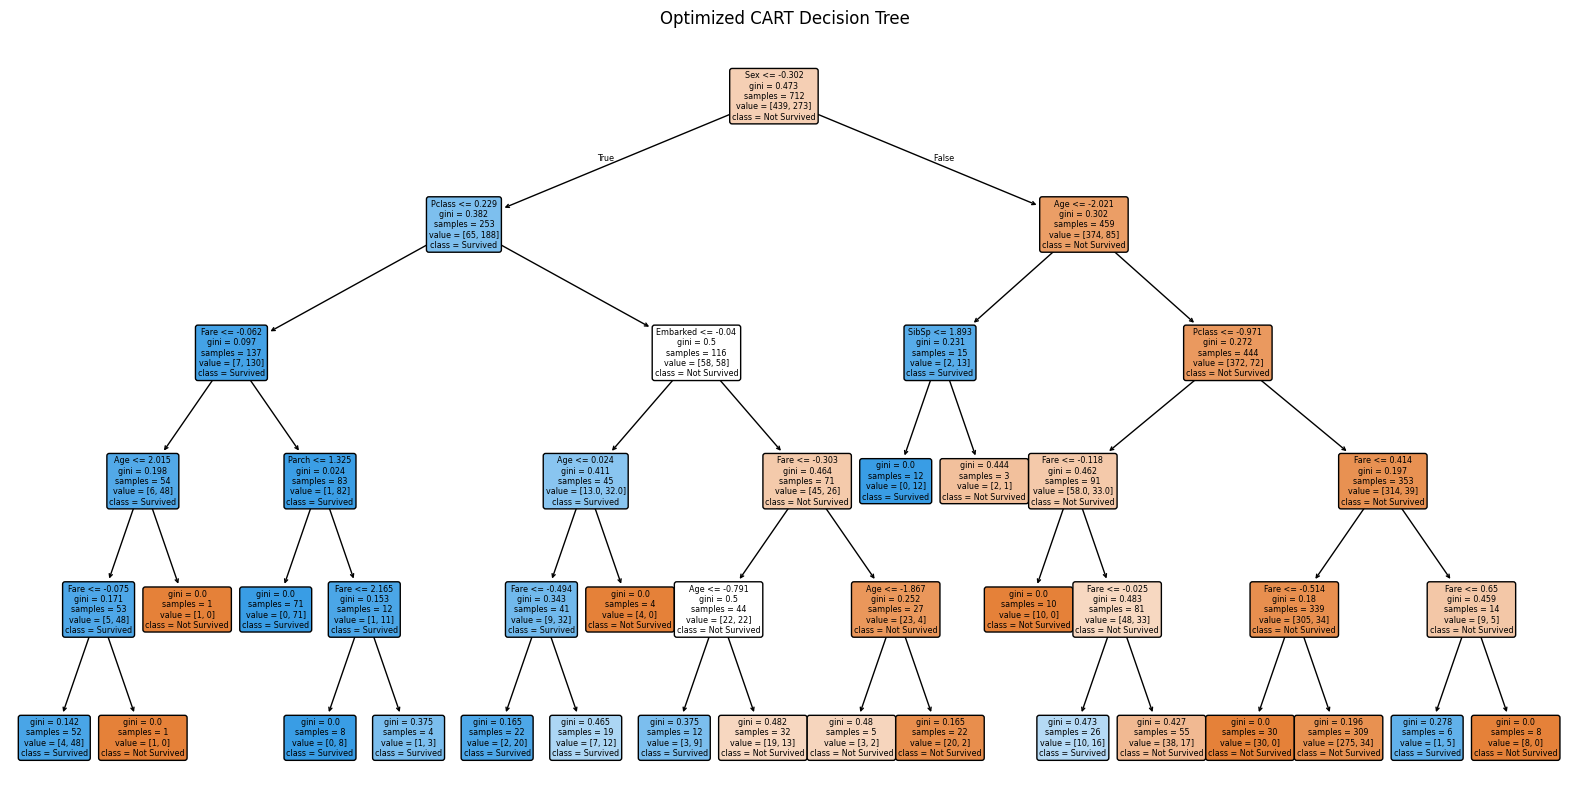

In [86]:
plt.figure(figsize=(20,10))

plot_tree(
    cart_model,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=['Not Survived','Survived']
)

plt.title("Optimized CART Decision Tree")
plt.show()